In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/Users/admin/cardiovascular_ml/data/cardio_train.csv', sep=';')
print(df.shape)
df.head()

(70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [55]:
# 흡연·음주 컬럼 고유값 확인
print("=== smoke 컬럼 고유값 ===")
print(df['smoke'].unique())
print(df['smoke'].value_counts())

print("\n=== alco 컬럼 고유값 ===")
print(df['alco'].unique())
print(df['alco'].value_counts())


=== smoke 컬럼 고유값 ===
[0 1]
smoke
0    62632
1     6043
Name: count, dtype: int64

=== alco 컬럼 고유값 ===
[0 1]
alco
0    64996
1     3679
Name: count, dtype: int64


In [20]:
# 나이 변환 (일 → 세)
df['age'] = (df['age'] / 365).astype(int)

# 확인
print(df['age'].describe())
df.head()

count    70000.000000
mean        52.840671
std          6.766774
min         29.000000
25%         48.000000
50%         53.000000
75%         58.000000
max         64.000000
Name: age, dtype: float64


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,2,51,1,165,64.0,130,70,3,1,0,0,0,1
3,3,48,2,169,82.0,150,100,1,1,0,0,1,1
4,4,47,1,156,56.0,100,60,1,1,0,0,0,0


In [21]:
# 결측치 확인
print(df.isnull().sum())

# 기초 통계
df.describe()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,52.840671,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,6.766774,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,29.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,48.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,53.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,58.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,64.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [22]:
# 말도 안 되는 혈압값 제거
df = df[
    (df['ap_hi'] >= 80) & (df['ap_hi'] <= 250) &
    (df['ap_lo'] >= 50) & (df['ap_lo'] <= 200)
]

# BMI 계산
df['bmi'] = df['weight'] / ((df['height'] / 100) ** 2)
df = df[(df['bmi'] >= 10) & (df['bmi'] <= 60)]

print(f"이상치 제거 후: {df.shape}")

이상치 제거 후: (68675, 14)


In [23]:
# 심혈관 질환 있는 사람 vs 없는 사람 비율
print(df['cardio'].value_counts())
print(df['cardio'].value_counts(normalize=True))

cardio
0    34682
1    33993
Name: count, dtype: int64
cardio
0    0.505016
1    0.494984
Name: proportion, dtype: float64


In [24]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Mac 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 폰트 적용 확인
print("폰트 설정 완료!")

폰트 설정 완료!


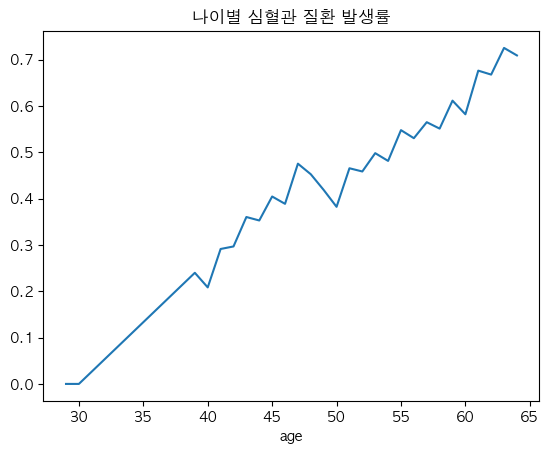

In [25]:
# 나이별 발생률
df.groupby('age')['cardio'].mean().plot()
plt.title('나이별 심혈관 질환 발생률')
plt.show()

In [26]:
# 흡연자 vs 비흡연자 심혈관 질환 비율
print("흡연별 심혈관 질환 비율:")
print(df.groupby('smoke')['cardio'].mean())

print("\n음주별 심혈관 질환 비율:")
print(df.groupby('alco')['cardio'].mean())

흡연별 심혈관 질환 비율:
smoke
0    0.497477
1    0.469138
Name: cardio, dtype: float64

음주별 심혈관 질환 비율:
alco
0    0.495892
1    0.478934
Name: cardio, dtype: float64


In [27]:
print("흡연 분포:")
print(df['smoke'].value_counts())

print("\n음주 분포:")
print(df['alco'].value_counts())

흡연 분포:
smoke
0    62632
1     6043
Name: count, dtype: int64

음주 분포:
alco
0    64996
1     3679
Name: count, dtype: int64


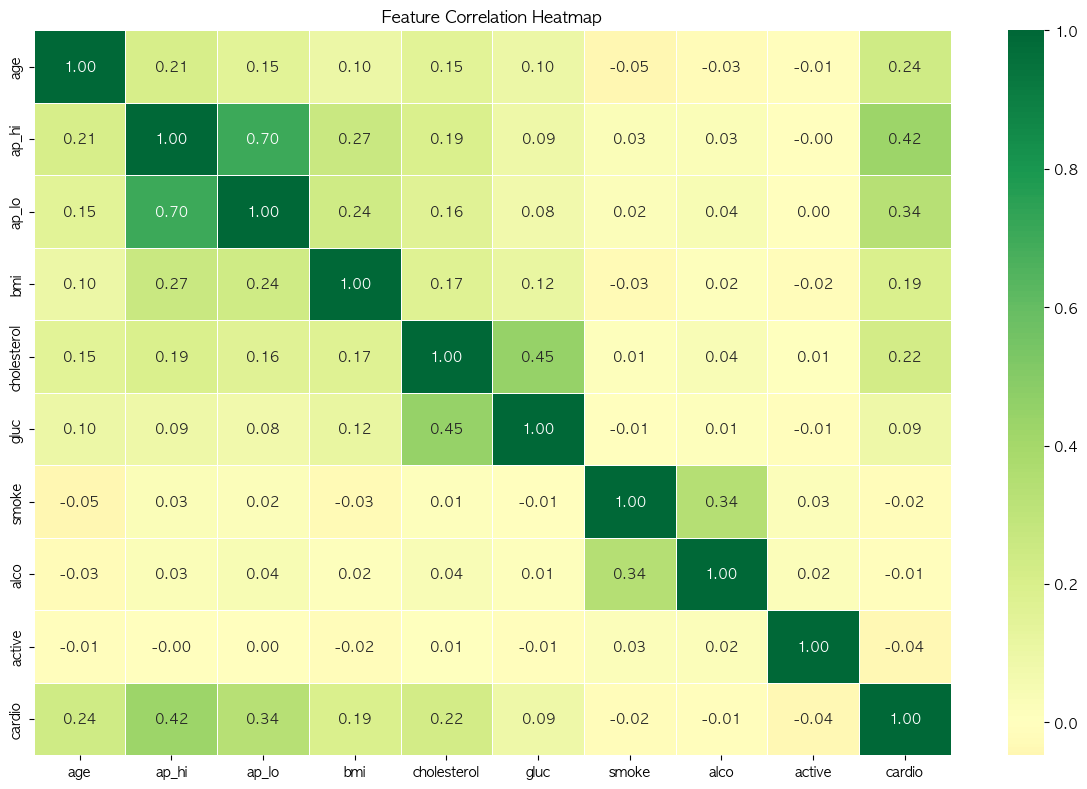

In [28]:
import seaborn as sns

plt.figure(figsize=(12, 8))
corr = df[['age', 'ap_hi', 'ap_lo', 'bmi',
           'cholesterol', 'gluc', 'smoke',
           'alco', 'active', 'cardio']].corr()

sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# 한글 폰트
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

print("import 완료!")

import 완료!


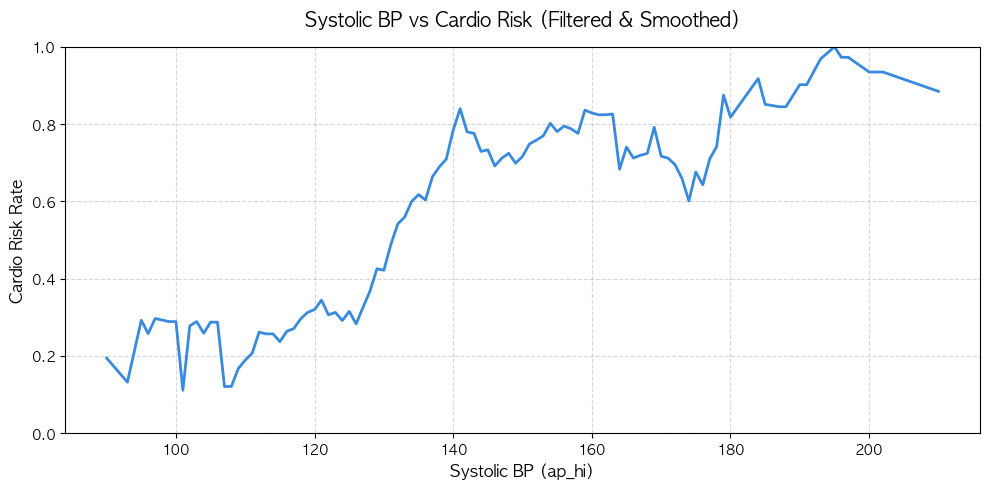

In [43]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. 데이터 필터링 (이상치 제거: 혈압 80~220 사이만 추출)
# 'df'가 현재 사용 중인 데이터프레임 이름이라고 가정합니다.
df_filtered = df[(df['ap_hi'] >= 80) & (df['ap_hi'] <= 220)]

# 2. 혈압별 발생률 계산 및 이동평균 적용 (데이터를 부드럽게)
# window=5는 주변 5개 값을 평균 내어 그래프의 노이즈를 줄여줍니다.
risk_profile = df_filtered.groupby('ap_hi')['cardio'].mean().rolling(window=5, center=True).mean()

# 3. 그래프 도화지(Figure와 Axes) 생성
# 여기서 axes를 정의해야 'NameError'가 발생하지 않습니다.
fig, ax = plt.subplots(figsize=(10, 5))

# 4. 시각화 실행
risk_profile.plot(ax=ax, color='#378ADD', linewidth=2)

# 5. 그래프 꾸미기
ax.set_title('Systolic BP vs Cardio Risk (Filtered & Smoothed)', fontsize=14, pad=15)
ax.set_xlabel('Systolic BP (ap_hi)', fontsize=12)
ax.set_ylabel('Cardio Risk Rate', fontsize=12)
ax.set_ylim(0, 1) # 확률이므로 0~1 범위 고정
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [44]:
# IQR 방법으로 이상치 탐지
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    print(f"{column}: 이상치 {len(outliers)}개 ({len(outliers)/len(df)*100:.1f}%)")
    print(f"  정상 범위: {lower:.1f} ~ {upper:.1f}")
    return lower, upper

# 수치형 피처 이상치 확인
num_features = ['ap_hi', 'ap_lo', 'bmi', 'age', 'height', 'weight']
print("=== IQR 이상치 탐지 ===")
for feat in num_features:
    detect_outliers_iqr(df, feat)

=== IQR 이상치 탐지 ===
ap_hi: 이상치 1045개 (1.5%)
  정상 범위: 90.0 ~ 170.0
ap_lo: 이상치 3563개 (5.2%)
  정상 범위: 65.0 ~ 105.0
bmi: 이상치 1961개 (2.9%)
  정상 범위: 14.5 ~ 39.5
age: 이상치 4개 (0.0%)
  정상 범위: 33.0 ~ 73.0
height: 이상치 461개 (0.7%)
  정상 범위: 142.5 ~ 186.5
weight: 이상치 1714개 (2.5%)
  정상 범위: 39.5 ~ 107.5


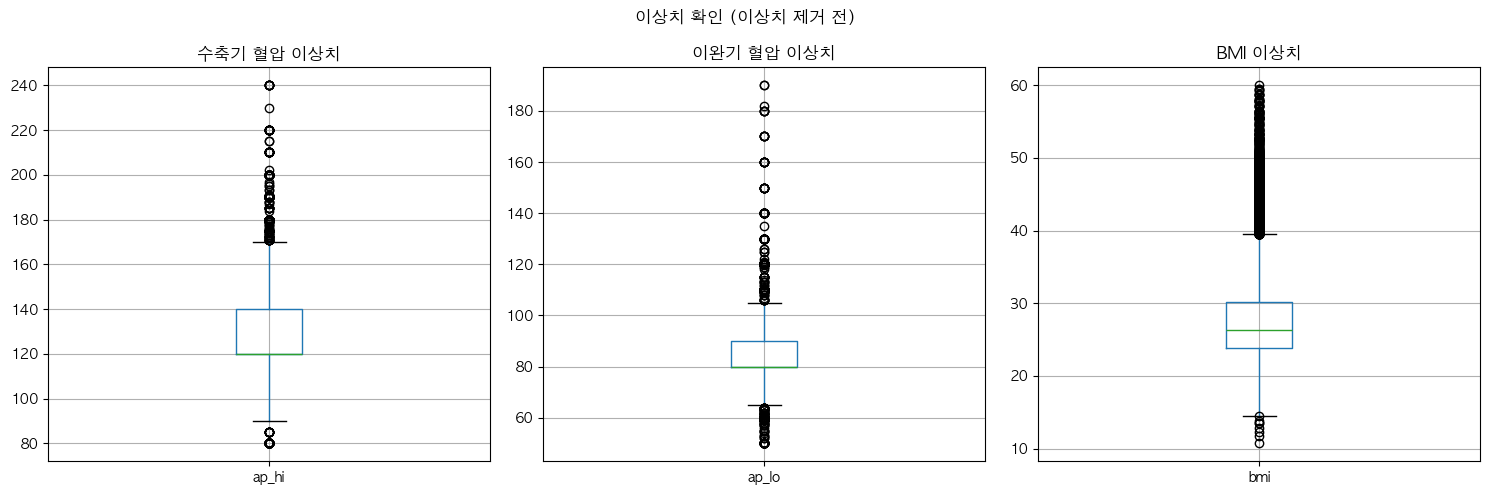

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

df.boxplot(column='ap_hi', ax=axes[0])
axes[0].set_title('수축기 혈압 이상치')

df.boxplot(column='ap_lo', ax=axes[1])
axes[1].set_title('이완기 혈압 이상치')

df.boxplot(column='bmi', ax=axes[2])
axes[2].set_title('BMI 이상치')

plt.suptitle('이상치 확인 (이상치 제거 전)')
plt.tight_layout()
plt.show()

In [48]:
# IQR 기반 이상치 제거
def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_clean = df_clean[
            (df_clean[col] >= lower) &
            (df_clean[col] <= upper)
        ]
    return df_clean

df_clean = remove_outliers_iqr(df, ['ap_hi', 'ap_lo', 'bmi', 'height', 'weight'])
print(f"이상치 제거 전: {df.shape}")
print(f"이상치 제거 후: {df_clean.shape}")
print(f"제거된 행 수: {df.shape[0] - df_clean.shape[0]}")

이상치 제거 전: (68675, 14)
이상치 제거 후: (60969, 14)
제거된 행 수: 7706


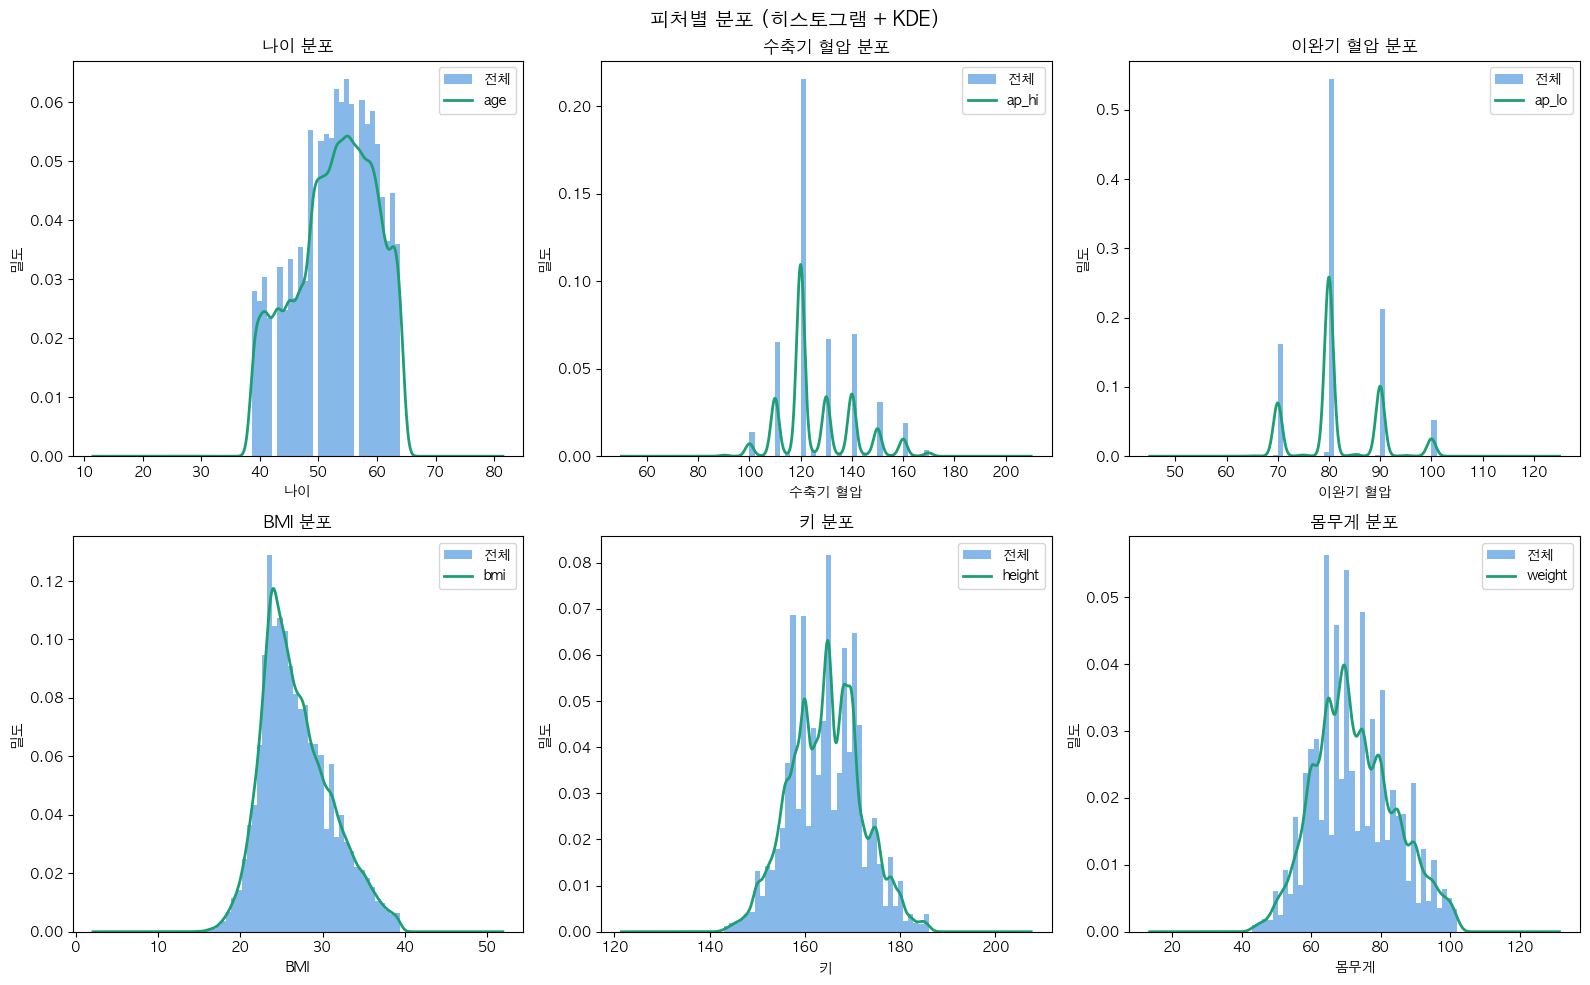

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ['age', 'ap_hi', 'ap_lo', 'bmi', 'height', 'weight']
labels   = ['나이', '수축기 혈압', '이완기 혈압', 'BMI', '키', '몸무게']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (feat, label) in enumerate(zip(features, labels)):
    # 히스토그램 + KDE
    axes[i].hist(df_clean[feat], bins=40,
                 alpha=0.6, color='#378ADD',
                 density=True, label='전체')
    df_clean[feat].plot.kde(ax=axes[i],
                             color='#1D9E75',
                             linewidth=2)
    axes[i].set_title(f'{label} 분포')
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('밀도')
    axes[i].legend()

plt.suptitle('피처별 분포 (히스토그램 + KDE)', fontsize=14)
plt.tight_layout()
plt.show()

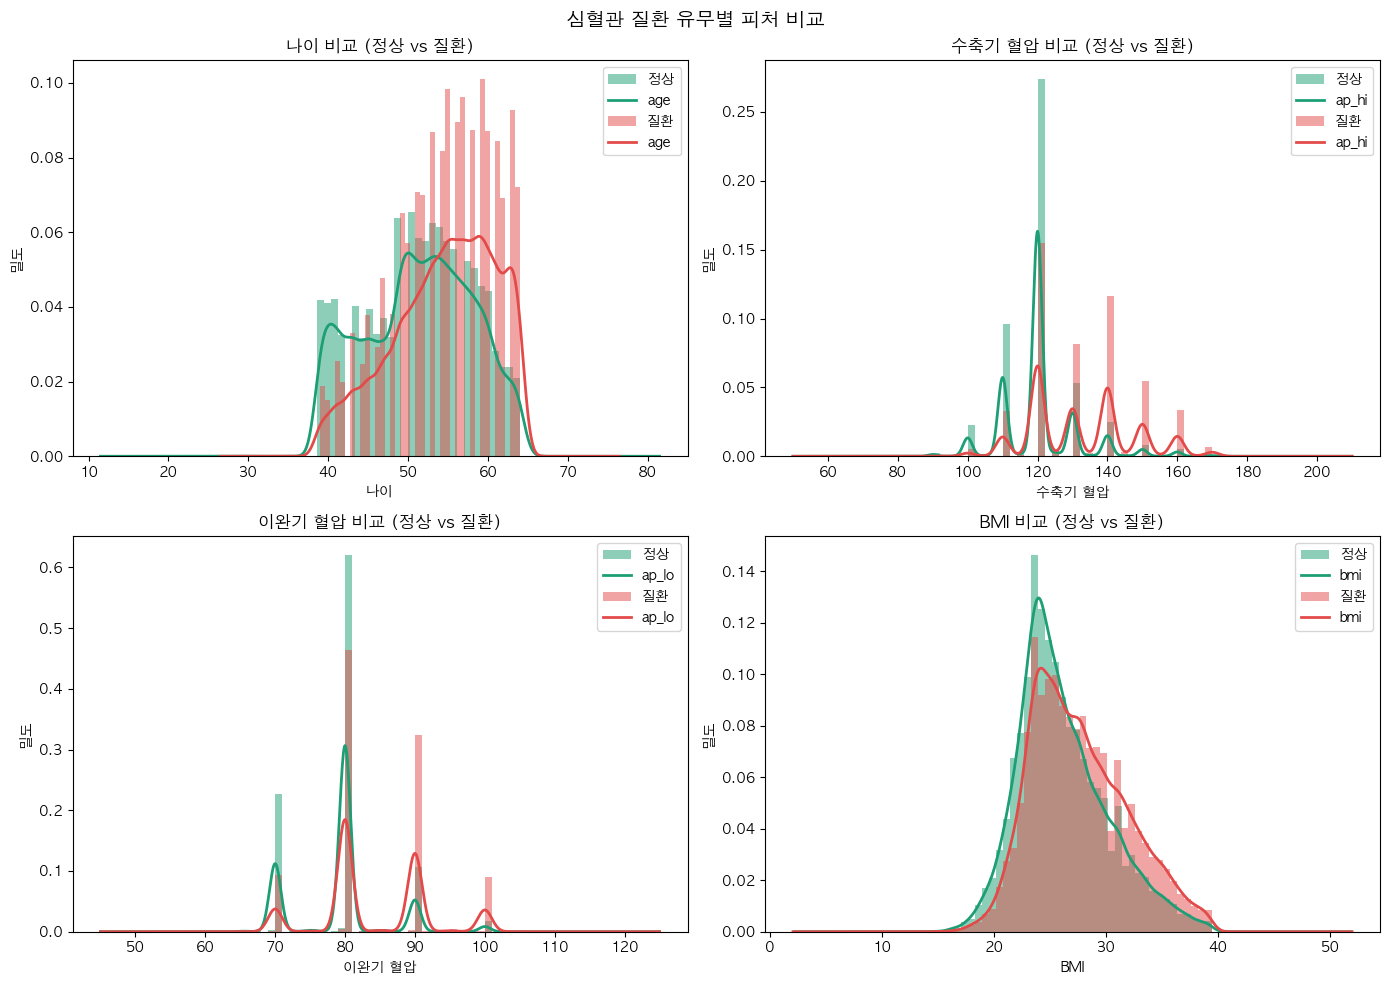

In [50]:
# 질환 유무에 따라 분리
df_normal  = df_clean[df_clean['cardio'] == 0]
df_disease = df_clean[df_clean['cardio'] == 1]

features = ['age', 'ap_hi', 'ap_lo', 'bmi']
labels   = ['나이', '수축기 혈압', '이완기 혈압', 'BMI']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (feat, label) in enumerate(zip(features, labels)):
    # 정상
    axes[i].hist(df_normal[feat], bins=40,
                 alpha=0.5, color='#1D9E75',
                 density=True, label='정상')
    df_normal[feat].plot.kde(ax=axes[i],
                              color='#1D9E75',
                              linewidth=2)
    # 질환
    axes[i].hist(df_disease[feat], bins=40,
                 alpha=0.5, color='#E24B4A',
                 density=True, label='질환')
    df_disease[feat].plot.kde(ax=axes[i],
                               color='#E24B4A',
                               linewidth=2)
    axes[i].set_title(f'{label} 비교 (정상 vs 질환)')
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('밀도')
    axes[i].legend()

plt.suptitle('심혈관 질환 유무별 피처 비교', fontsize=14)
plt.tight_layout()
plt.show()

In [52]:
print("=== 심혈관 질환 유무별 평균값 비교 ===\n")
compare_features = ['age', 'ap_hi', 'ap_lo', 'bmi',
                    'cholesterol', 'gluc']
compare_labels   = ['나이', '수축기혈압', '이완기혈압',
                    'BMI', '콜레스테롤', '혈당']

print(f"{'피처':<12} {'정상':>10} {'질환':>10} {'차이':>10}")
print("-" * 45)
for feat, label in zip(compare_features, compare_labels):
    normal_mean  = df_normal[feat].mean()
    disease_mean = df_disease[feat].mean()
    diff = disease_mean - normal_mean
    print(f"{label:<12} {normal_mean:>10.2f} {disease_mean:>10.2f} {diff:>+10.2f}")

=== 심혈관 질환 유무별 평균값 비교 ===

피처                   정상         질환         차이
---------------------------------------------
나이                51.32      54.53      +3.21
수축기혈압            120.22     132.51     +12.29
이완기혈압             79.10      84.23      +5.12
BMI               26.15      27.60      +1.45
콜레스테롤              1.21       1.50      +0.29
혈당                 1.17       1.27      +0.10
